In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from pathlib import Path
from tqdm import tqdm

# グラフの色指定
colors = ["tab:red", "tab:purple", "tab:blue", "tab:pink"]
markers = ["o", "s", "D", "P"]

# グラフ全体のフォント設定
# plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
# plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
# plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
# plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
# plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
# plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
# plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
# plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
# plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
# plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [40]:
network_type_list = ["ER", "BA"]
N = 20000
z = 6
z_bar = 6
cmin = 2.00
file_type = "final"
ini_type = "nonbfs"
index_cols = [] if file_type == "final" else ["time"]
index_cols.extend(["itr", "lambda", "mu", "rho", "c"])

In [41]:
sim_results=[[] for _ in range(len(network_type_list))]
rho0_values = []

for nidx, network_type in enumerate(network_type_list):
    sim_path = os.path.abspath(os.path.join('..',f'java-project/output/sis/lock/{network_type}/z={z}/N={N}cMin={cmin:.2f}{file_type}{ini_type}'))
    print(os.path.relpath(sim_path))
    for path in Path(sim_path).glob('**/results_*.csv'):
        sim_results[nidx].append(pd.read_csv(path))
    sim_results[nidx] = pd.concat(sim_results[nidx])
    sim_results[nidx] = xr.Dataset.from_dataframe(sim_results[nidx].set_index(index_cols))
    if (nidx==0):
        rho0_values = sim_results[nidx].coords["rho"].values

if network_type == "TwoRR":
    N = 2 * N

../java-project/output/sis/lock/ER/z=6/N=20000cMin=2.00finalnonbfs
../java-project/output/sis/lock/BA/z=6/N=20000cMin=2.00finalnonbfs


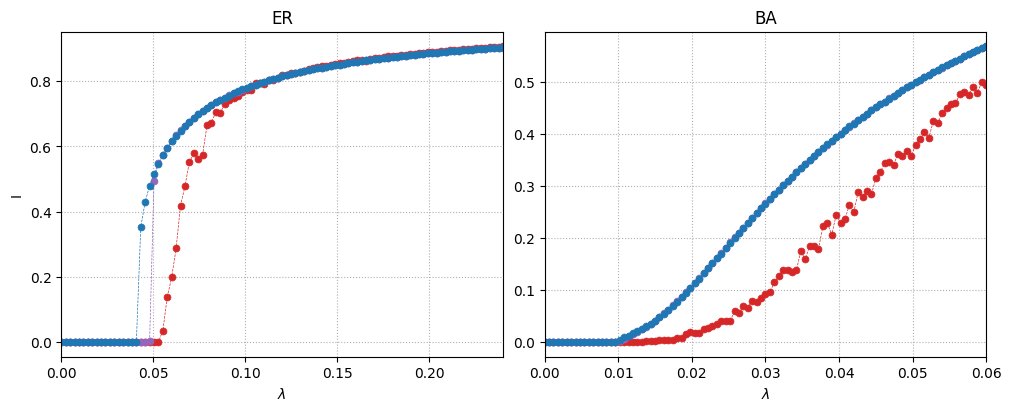

In [42]:
fig, axs = plt.subplots(1, len(network_type_list), figsize=(5*len(network_type_list), 4), constrained_layout=True)
if len(network_type_list) == 1:
    axs = [axs]
for nidx, network_type in enumerate(network_type_list):
    for r_idx, rho in enumerate(rho0_values):
        I = sim_results[nidx]["I"]
        I_rho = I.sel(rho=rho).mean(dim="itr")/N
        I_rho.plot(ax=axs[nidx], marker="o", linewidth=0.5, markersize=5, ls="--", markeredgewidth=0.5, color=colors[r_idx])
    axs[nidx].set_title(f"{network_type}")
    min_lambda = I["lambda"].min()
    max_lambda = I["lambda"].max()
    axs[nidx].set_xlim(min_lambda, max_lambda)
    axs[nidx].grid(True, linestyle=":")
    axs[nidx].set_xlabel(r"$\lambda$")
    if nidx == 0:
        axs[nidx].set_ylabel("I")
    else:
        axs[nidx].set_ylabel("")
plt.show()


100%|██████████| 101/101 [00:02<00:00, 40.86it/s]


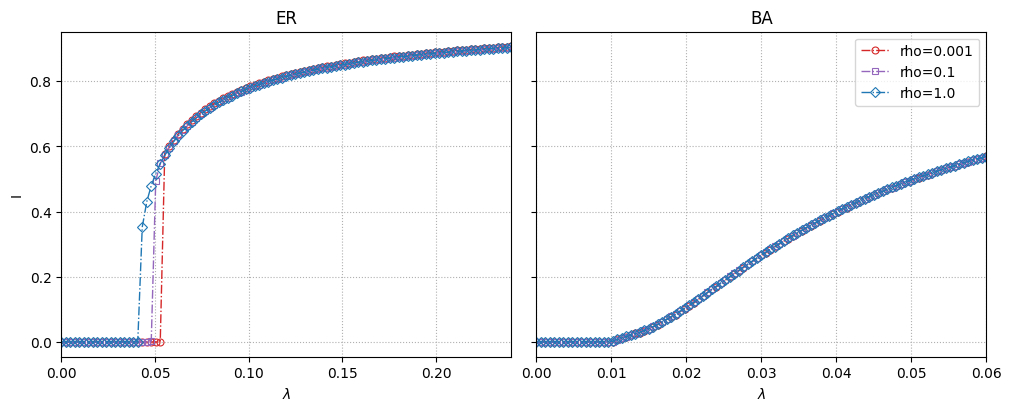

In [44]:
threshold = 3

fig, axs = plt.subplots(1, len(network_type_list), figsize=(5*len(network_type_list), 4), constrained_layout=True, sharey=True)
if len(network_type_list) == 1:
    axs = [axs]
for nidx, network_type in enumerate(network_type_list):
    for r_idx, rho in enumerate(rho0_values):
        I = sim_results[nidx]["I"].sel(rho=rho).squeeze()

        plot = np.zeros(len(I["lambda"].values))
        for lidx, lamb in enumerate(tqdm(I["lambda"].values)):
            valid_num = 0
            valid_sum = 0
            for itr in range(len(I["itr"].values)):
                check = threshold * N * rho if rho < 0.05 else 0
                if I[itr, lidx] >= check:
                    valid_num += 1
                    valid_sum += I[itr, lidx]
            plot[lidx] = valid_sum / valid_num if valid_num > 0 else 0
        axs[nidx].plot(I["lambda"].values, plot/N, marker=markers[r_idx], linewidth=1.0, markersize=5, markerfacecolor="none",ls="-.", markeredgewidth=0.8, color=colors[r_idx], label=f"rho={rho}")
    axs[nidx].set_title(f"{network_type}")
    min_lambda = I["lambda"].min()
    max_lambda = I["lambda"].max()
    axs[nidx].set_xlim(min_lambda, max_lambda)
    axs[nidx].grid(True, linestyle=":")
    axs[nidx].set_xlabel(r"$\lambda$")
    if nidx == 0:
        axs[nidx].set_ylabel("I")
    else:
        axs[nidx].set_ylabel("")

plt.legend()
plt.show()
